In [9]:
from astropy.table import Table
tiles_ref = Table.read('/home/hmf/work/FA_test/inputs/tiles_use.fits')

print(tiles_ref.keys())

['TILEID', 'RA', 'DEC', 'PASS', 'IN_DESI', 'EBV_MED', 'AIRMASS', 'STAR_DENSITY', 'EXPOSEFAC', 'PROGRAM', 'OBSCONDITIONS', 'BRIGHTRA', 'BRIGHTDEC', 'BRIGHTVTMAG', 'CENTERID', 'IMAGEFRAC_G', 'IMAGEFRAC_R', 'IMAGEFRAC_Z', 'IMAGEFRAC_GR', 'IMAGEFRAC_GRZ', 'IN_IMAGING']


In [ ]:
for key in tiles_ref.keys():
    print(key, np.unique(tiles_ref[key]))


TILEID TILEID
------
  5904
  6585
  6606
RA         RA        
------------------
119.64623887606805
119.87617878134363
122.31126805307166
DEC        DEC        
------------------
16.653639342687278
18.233639342687276
19.633639342687275
PASS PASS
----
   1
IN_DESI IN_DESI
-------
      1
EBV_MED   EBV_MED  
-----------
0.033587113
0.041029606
0.041789755
AIRMASS  AIRMASS 
---------
 1.052943
1.0593417
1.0674278
STAR_DENSITY STAR_DENSITY
------------
    4346.512
   4880.2944
    5490.331
EXPOSEFAC EXPOSEFAC
---------
1.3309865
1.3754071
1.3794681
PROGRAM PROGRAM
-------
   DARK
OBSCONDITIONS OBSCONDITIONS
-------------
            1
BRIGHTRA   BRIGHTRA  
------------
118.91626556
119.24778528
120.19713778
120.20040778
120.37619417
121.18882889
123.05297917
123.05473556
BRIGHTDEC  BRIGHTDEC 
-----------
   15.79038
16.45532222
 17.3087075
17.64809306
17.64844056
18.84206444
19.81623472
19.88406306
BRIGHTVTMAG BRIGHTVTMAG
-----------
      5.302
      5.359
      5.738
      5.853
    

# MUST tiles

In [6]:
#!/usr/bin/env python3
import sys
sys.path.append('/data/users/hmf/must_science_white_paper_1-master/figs/scripts/')
from common_setup import *
import matplotlib.ticker as mt
from matplotlib.path import Path
from matplotlib.patches import Circle, Ellipse
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
from cartopy.feature import ShapelyFeature
from cartopy.geodesic import Geodesic
import shapely.geometry as sg

# IO settings
ilogo = '/data/users/hmf/must_science_white_paper_1-master/figs/data/MUST_logo/MUST_logo.svg'
ifile = '/data/users/hmf/must_science_white_paper_1-master/figs/data/data_tiles.npz'
# ofile = '/data/users/hmf/must_science_white_paper_1-master/figs/scripts/../output/tiles.pdf'

# Figure settings
figl = 0.04
figr = 0.96
figb = 0.08
figt = 0.88
wspace = 0.35
hspace = 0
figw = textwidth
figh = figw * (figr - figl) / (2 + wspace) / (figt - figb)

foot_keys = ['DECaLS', 'CSST']
foot_colors = [rgba2rgb('r', 0.9), 'mediumorchid']
inset_coords = [[0.35, 0.68, 0.3, 0.2], [0.35, figb, 0.3, 0.2]]

gal_bounds = {'color': 'brown', 'lw': 1.2, 'ls': '--'}
ecl_plane = {'color': 'royalblue', 'lw': 1.4, 'ls': '-', 'alpha': 0.7}
ecl_bounds = {'color': 'tab:blue', 'lw': 1, 'ls': (0, (6, 3))}

## Settings for the ecliptic plane text
ecl_text_center = (406.5, 127.5)
ecl_text_radius = 81
ecl_text_start = np.radians(250)
ecl_text_delta = np.radians(3.6)
ecl_text_color = 'royalblue'

## Settings for the grid lines and labels
ra_grid = np.arange(180, -180, -60)
dec_grid = np.arange(-10, 90, 20)

## Settings for the zoomed-in tile pattern
ra_lims = [[-160, -150], [100, 110]]
dec_lims = [[5, 15], [20, 30]]
zoom_coords = [[-0.055, 0.65, 0.23, 0.23], [0.825, 0.65, 0.23, 0.23]]



# Read data
data = np.load(ifile, allow_pickle=True)
tiles = data['tiles'].item()
planes = data['planes'].item()
footprints = data['footprints'].item()
print(tiles, footprints)



# Save the figure

{'CSST': {'RA': array([ 180.        ,   90.        , -176.47674861, ..., -138.10080862,
       -140.2454027 , -136.31439017]), 'DEC': array([58.28252559, 31.71747441, 59.0158712 , ..., -8.24332295,
       -9.26124941, -9.26282873]), 'diameter': 2.56}, 'DECaLS': {'RA': array([ 180.        ,   90.        ,   31.71747441, ..., -148.39123154,
       -149.19334035, -150.00203316]), 'DEC': array([58.28252559, 31.71747441,  0.        , ..., -5.10185543,
       -6.99484532, -8.88262108]), 'diameter': 2.56}} {'CSST': <MULTIPOLYGON (((-164.32 -9.59, -163.996 -9.452, -163.672 -9.314, -163.348 -...>, 'DECaLS': <MULTIPOLYGON (((-81.079 -9.897, -80.596 -9.859, -80.596 -9.708, -80.596 -9....>}


In [10]:
print(planes)

{'ecliptic': {'RA': array([-180.        , -179.83370689, -179.50304763, ...,  179.50497657,
        179.83563589,  180.        ]), 'DEC': array([-6.38015673e-06,  7.20903342e-02,  2.15445025e-01, ...,
       -2.14621525e-01, -7.12667742e-02, -6.38015673e-06]), 'RA_lower': array([-180.        , -179.99490739, -179.66437353, ...,  179.34329045,
        179.6743155 ,  180.        ]), 'DEC_lower': array([-16.387052  , -16.38484488, -16.2414871 , ..., -16.67155573,
       -16.52820268, -16.387052  ]), 'RA_upper': array([-180.        , -179.67230379, -179.34127735, ...,  179.66638234,
        179.99691767,  180.        ]), 'DEC_upper': array([16.38697047, 16.5289887 , 16.67233794, ..., 16.24228055,
       16.38563464, 16.38697047])}, 'galactic': {'RA': array([-180.        , -179.8900639 , -179.13314446, ...,  178.58540392,
        179.34939117,  180.        ]), 'DEC': array([-62.27648959, -62.26638504, -62.1923424 , ..., -62.40202247,
       -62.33628894, -62.27648959]), 'RA_lower': array([-

In [5]:
import numpy as np
from astropy.io import fits
from astropy.table import Table

obs_data = {
    'CSST': ['DARK', 1],
    'DECaLS': ['GRAY', 2]
}
for fp in tiles.keys():
    print(fp)
    # ras = tiles[fp]['RA']
    # decs = tiles[fp]['DEC']

    ras = (-1*tiles[fp]['RA'] + 360.0) % 360.0
    decs = tiles[fp]['DEC']

    ras = ras[5:7]
    decs = decs[5:7]

    print(min(ras), max(ras), min(decs), max(decs))

    tab = Table([ras, decs], names=['RA', 'DEC'])
    obs_con, obs_num = obs_data[fp]
    npoints = len(tab)
    tab.add_column(np.arange(npoints).astype('int64') + 1, name='TILEID')
    tab.add_column(np.array([1]*npoints), name='IN_DESI')
    tab.add_column(np.array([obs_con]*npoints), name='PROGRAM')
    tab.add_column(np.array([obs_num]*npoints).astype(int), name='OBSCONDITIONS') # DARK

    # create fits
    hdus = fits.HDUList([fits.PrimaryHDU(), fits.BinTableHDU(tab)])
    outfile = f'/home/hmf/work/FA_test/MUST_mock/tiles_{fp}_{obs_con}_{obs_num}_test.fits'
    hdus.writeto(outfile, overwrite=True)
    print('Written to: %s'%outfile)




CSST
172.65271967837134 176.74226239658947 61.72997468080018 63.131920318476524
Written to: /home/hmf/work/FA_test/MUST_mock/tiles_CSST_DARK_1_test.fits
DECaLS
148.282525588539 183.52325139063757 0.0 59.01587119612232
Written to: /home/hmf/work/FA_test/MUST_mock/tiles_DECaLS_GRAY_2_test.fits


[ 180.           90.           31.71747441 ... -148.39123154 -149.19334035
 -150.00203316] 2.56
[ 180.           90.         -176.47674861 ... -138.10080862 -140.2454027
 -136.31439017] 2.56


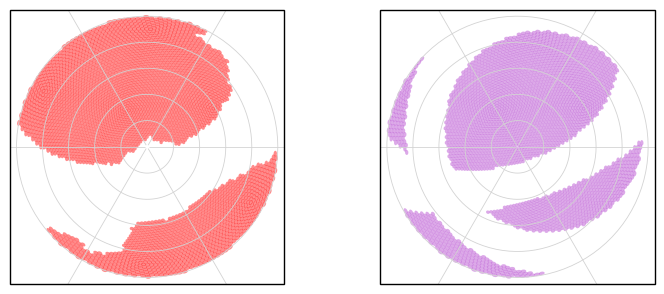

In [53]:
#!/usr/bin/env python3
import sys
sys.path.append('/data/users/hmf/must_science_white_paper_1-master/figs/scripts/')
from common_setup import *
import matplotlib.ticker as mt
from matplotlib.path import Path
from matplotlib.patches import Circle, Ellipse
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
from cartopy.feature import ShapelyFeature
from cartopy.geodesic import Geodesic
import shapely.geometry as sg

# IO settings
ilogo = '/data/users/hmf/must_science_white_paper_1-master/figs/data/MUST_logo/MUST_logo.svg'
ifile = '/data/users/hmf/must_science_white_paper_1-master/figs/data/data_tiles.npz'
# ofile = '/data/users/hmf/must_science_white_paper_1-master/figs/scripts/../output/tiles.pdf'

# Figure settings
figl = 0.04
figr = 0.96
figb = 0.08
figt = 0.88
wspace = 0.35
hspace = 0
figw = textwidth
figh = figw * (figr - figl) / (2 + wspace) / (figt - figb)

foot_keys = ['DECaLS', 'CSST']
foot_colors = [rgba2rgb('r', 0.9), 'mediumorchid']
inset_coords = [[0.35, 0.68, 0.3, 0.2], [0.35, figb, 0.3, 0.2]]

gal_bounds = {'color': 'brown', 'lw': 1.2, 'ls': '--'}
ecl_plane = {'color': 'royalblue', 'lw': 1.4, 'ls': '-', 'alpha': 0.7}
ecl_bounds = {'color': 'tab:blue', 'lw': 1, 'ls': (0, (6, 3))}

## Settings for the ecliptic plane text
ecl_text_center = (406.5, 127.5)
ecl_text_radius = 81
ecl_text_start = np.radians(250)
ecl_text_delta = np.radians(3.6)
ecl_text_color = 'royalblue'

## Settings for the grid lines and labels
ra_grid = np.arange(180, -180, -60)
dec_grid = np.arange(-10, 90, 20)

## Settings for the zoomed-in tile pattern
ra_lims = [[-160, -150], [100, 110]]
dec_lims = [[5, 15], [20, 30]]
zoom_coords = [[-0.055, 0.65, 0.23, 0.23], [0.825, 0.65, 0.23, 0.23]]

plt.rcParams.update(plot_settings)


# Read data
data = np.load(ifile, allow_pickle=True)
tiles = data['tiles'].item()
planes = data['planes'].item()
footprints = data['footprints'].item()
dens = data['stardens'].item()


# Create figure and subplots
fig = plt.figure(figsize=(figw, figh))
fig.subplots_adjust(left=figl, right=figr, bottom=figb, top=figt, wspace=wspace, hspace=hspace)

#ax = [fig.add_subplot(1, 2, i+1, projection=ccrs.NorthPolarStereo()) for i in range(2)]
ax = [fig.add_subplot(1, 2, i+1, projection=ccrs.AzimuthalEquidistant(central_longitude=-30, central_latitude=90)) for i in range(2)]

# Set the boundaries of the subplots
theta = np.linspace(0, 2*np.pi, 1000)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = Path(verts * radius + center)

# Plot the main panels
for a, key, color in zip(ax, foot_keys, foot_colors):
  # Plot the stellar density
#   a.pcolormesh(dens['RA'], dens['DEC'], dens['dens'], vmin=1000, vmax=30000, transform=ccrs.PlateCarree(), cmap='gist_heat_r', rasterized=True, zorder=1)

  # Plot the MUST tiles
  ra_tile = tiles[key]['RA']
  dec_tile = tiles[key]['DEC']
  delta_dec = tiles[key]['diameter']
  print(ra_tile, delta_dec)
  delta_ra = delta_dec / np.cos(np.radians(dec_tile))

  ## Create a list of ellipses for the tiles
  ellipses = [
    Ellipse((ra, dec), dra, delta_dec) for ra, dec, dra in zip(ra_tile, dec_tile, delta_ra)
  ]
  collection = PatchCollection(ellipses, fc=color, ec='none', lw=0, alpha=0.5, transform=ccrs.PlateCarree(), rasterized=True, zorder=2)
  a.add_collection(collection)

  # # Plot the galactic plane
  # for bound in ['upper', 'lower']:
  #   a.plot(planes['galactic'][f'RA_{bound}'], planes['galactic'][f'DEC_{bound}'], transform=ccrs.PlateCarree(), color=gal_bounds['color'], ls=gal_bounds['ls'], lw=gal_bounds['lw'], zorder=5)

  # # Set the boundary
  # a.set_boundary(circle, transform=a.transAxes)

  a.set_extent([-180, 180, -15, 90], ccrs.PlateCarree())
  a.gridlines(draw_labels=False, xlocs=ra_grid, ylocs=dec_grid, color='lightgray', lw=0.6, zorder=3)


/home/hmf/miniconda3/envs/DESI_FA/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:769: UserWarning: Approximating coordinate system <Geographic 2D CRS: +proj=lonlat +datum=WGS84 +ellps=WGS84 +no_defs +t ...>
Name: unknown
Axis Info [ellipsoidal]:
- lon[east]: Longitude (degree)
- lat[north]: Latitude (degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
 with the PlateCarree projection.
  warnings.warn(f'Approximating coordinate system {crs!r} with '
/home/hmf/miniconda3/envs/DESI_FA/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:769: UserWarning: Approximating coordinate system <Geographic 2D CRS: +proj=lonlat +datum=WGS84 +ellps=WGS84 +no_defs +t ...>
Name: unknown
Axis Info [ellipsoidal]:
- lon[east]: Longitude (degree)
- lat[north]: Latitude (degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
 with the PlateCarree projection.
  warnings.warn(f'Appro

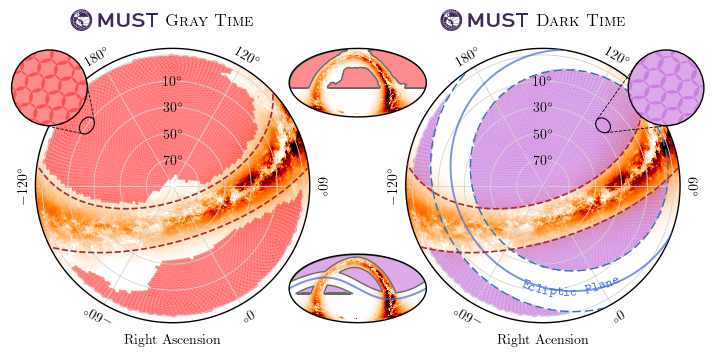

In [ ]:
#!/usr/bin/env python3
import sys
sys.path.append('/data/users/hmf/must_science_white_paper_1-master/figs/scripts/')
from common_setup import *
import matplotlib.ticker as mt
from matplotlib.path import Path
from matplotlib.patches import Circle, Ellipse
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
from cartopy.feature import ShapelyFeature
from cartopy.geodesic import Geodesic
import shapely.geometry as sg

# IO settings
ilogo = '/data/users/hmf/must_science_white_paper_1-master/figs/data/MUST_logo/MUST_logo.svg'
ifile = '/data/users/hmf/must_science_white_paper_1-master/figs/data/data_tiles.npz'
# ofile = '/data/users/hmf/must_science_white_paper_1-master/figs/scripts/../output/tiles.pdf'

# Figure settings
figl = 0.04
figr = 0.96
figb = 0.08
figt = 0.88
wspace = 0.35
hspace = 0
figw = textwidth
figh = figw * (figr - figl) / (2 + wspace) / (figt - figb)

foot_keys = ['DECaLS', 'CSST']
foot_colors = [rgba2rgb('r', 0.9), 'mediumorchid']
inset_coords = [[0.35, 0.68, 0.3, 0.2], [0.35, figb, 0.3, 0.2]]

gal_bounds = {'color': 'brown', 'lw': 1.2, 'ls': '--'}
ecl_plane = {'color': 'royalblue', 'lw': 1.4, 'ls': '-', 'alpha': 0.7}
ecl_bounds = {'color': 'tab:blue', 'lw': 1, 'ls': (0, (6, 3))}

## Settings for the ecliptic plane text
ecl_text_center = (406.5, 127.5)
ecl_text_radius = 81
ecl_text_start = np.radians(250)
ecl_text_delta = np.radians(3.6)
ecl_text_color = 'royalblue'

## Settings for the grid lines and labels
ra_grid = np.arange(180, -180, -60)
dec_grid = np.arange(-10, 90, 20)

## Settings for the zoomed-in tile pattern
ra_lims = [[-160, -150], [100, 110]]
dec_lims = [[5, 15], [20, 30]]
zoom_coords = [[-0.055, 0.65, 0.23, 0.23], [0.825, 0.65, 0.23, 0.23]]

plt.rcParams.update(plot_settings)


# Read data
data = np.load(ifile, allow_pickle=True)
tiles = data['tiles'].item()
planes = data['planes'].item()
footprints = data['footprints'].item()
dens = data['stardens'].item()


# Create figure and subplots
fig = plt.figure(figsize=(figw, figh))
fig.subplots_adjust(left=figl, right=figr, bottom=figb, top=figt, wspace=wspace, hspace=hspace)

#ax = [fig.add_subplot(1, 2, i+1, projection=ccrs.NorthPolarStereo()) for i in range(2)]
ax = [fig.add_subplot(1, 2, i+1, projection=ccrs.AzimuthalEquidistant(central_longitude=-30, central_latitude=90)) for i in range(2)]

# Set the boundaries of the subplots
theta = np.linspace(0, 2*np.pi, 1000)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = Path(verts * radius + center)

# Plot the main panels
for a, key, color in zip(ax, foot_keys, foot_colors):
  # Plot the stellar density
  a.pcolormesh(dens['RA'], dens['DEC'], dens['dens'], vmin=1000, vmax=30000, transform=ccrs.PlateCarree(), cmap='gist_heat_r', rasterized=True, zorder=1)

  # Plot the MUST tiles
  ra_tile = tiles[key]['RA']
  dec_tile = tiles[key]['DEC']
  delta_dec = tiles[key]['diameter']
  delta_ra = delta_dec / np.cos(np.radians(dec_tile))

  ## Create a list of ellipses for the tiles
  ellipses = [
    Ellipse((ra, dec), dra, delta_dec) for ra, dec, dra in zip(ra_tile, dec_tile, delta_ra)
  ]
  collection = PatchCollection(ellipses, fc=color, ec='none', lw=0, alpha=0.5, transform=ccrs.PlateCarree(), rasterized=True, zorder=2)
  a.add_collection(collection)

  # Plot the galactic plane
  for bound in ['upper', 'lower']:
    a.plot(planes['galactic'][f'RA_{bound}'], planes['galactic'][f'DEC_{bound}'], transform=ccrs.PlateCarree(), color=gal_bounds['color'], ls=gal_bounds['ls'], lw=gal_bounds['lw'], zorder=5)

  # Set the boundary
  a.set_boundary(circle, transform=a.transAxes)

  a.set_extent([-180, 180, -15, 90], ccrs.PlateCarree())
  a.gridlines(draw_labels=False, xlocs=ra_grid, ylocs=dec_grid, color='lightgray', lw=0.6, zorder=3)

## Plot the ecliptic plane for the CSST footprint
ax[1].plot(planes['ecliptic']['RA'], planes['ecliptic']['DEC'], transform=ccrs.PlateCarree(), color=ecl_plane['color'], ls=ecl_plane['ls'], lw=ecl_plane['lw'], alpha=ecl_plane['alpha'], zorder=4)
for bound in ['upper', 'lower']:
  ax[1].plot(planes['ecliptic'][f'RA_{bound}'], planes['ecliptic'][f'DEC_{bound}'], transform=ccrs.PlateCarree(), color=ecl_bounds['color'], ls=ecl_bounds['ls'], lw=ecl_bounds['lw'], zorder=4)

## Plot the grid labels
for a in ax:
  for ra in ra_grid:
    a.text(ra, -24, rf'${ra}^\circ$', ha='center', va='center', fontsize=plt.rcParams['xtick.labelsize'], rotation=ra-150, transform=ccrs.PlateCarree())
  for dec in dec_grid[1:]:
    a.text(150, dec + 1, rf'${dec}^\circ$', ha='center', va='center', fontsize=plt.rcParams['ytick.labelsize'], transform=ccrs.PlateCarree())

## Annotate the ecliptic plane
for i, letter in enumerate('Ecliptic Plane'):
  text_x = ecl_text_center[0] + ecl_text_radius * np.cos(ecl_text_start + i * ecl_text_delta)
  text_y = ecl_text_center[1] + ecl_text_radius * np.sin(ecl_text_start + i * ecl_text_delta)
  text_rot = np.degrees(ecl_text_start + i * ecl_text_delta) + 90
  ax[1].annotate(rf'\texttt{{{letter}}}', (text_x, text_y), xycoords='figure points', ha='center', va='center', rotation=text_rot, color=ecl_text_color)

## Add axis labels
fig.text(figl + (figr - figl) / (2 + wspace) / 2, 0.03, r'Right Ascension', ha='center', va='center', fontsize=plt.rcParams['axes.labelsize'])
fig.text(figr - (figr - figl) / (2 + wspace) / 2, 0.03, r'Right Acension', ha='center', va='center', fontsize=plt.rcParams['axes.labelsize'])
# for a in ax:
#   a.text(190, 40, r'Declination', ha='center', va='center', rotation=-60, fontsize=plt.rcParams['axes.labelsize'], transform=ccrs.PlateCarree())

## Add panel titles with MUST logo
for xlogo in [0.09, 0.618]:
  logo, logo_width, logo_height = logo_path(ilogo)
  axlogo = fig.add_axes([xlogo, 0.9, 0.125, 0.125])
  logo.set_transform(axlogo.transData)
  axlogo.add_artist(logo)
  axlogo.axis('off')
  axlogo.set_aspect('equal')
  axlogo.set_xlim(0, logo_width)
  axlogo.set_ylim(-logo_height, 0)

fig.text(figl + (figr - figl) / (2 + wspace) / 2 - 0.01, 0.98, r'\textsc{Gray Time}', ha='left', va='top', fontsize=plt.rcParams['axes.labelsize'] + 2)
fig.text(figr - (figr - figl) / (2 + wspace) / 2 - 0.01, 0.98, r'\textsc{Dark Time}', ha='left', va='top', fontsize=plt.rcParams['axes.labelsize'] + 2)


# Plot the inset panels for footprints
for coords, foot, color in zip(inset_coords, foot_keys, foot_colors):
  a = fig.add_axes(coords, projection=ccrs.Mollweide())
  a.pcolormesh(dens['RA'], dens['DEC'], dens['dens'], vmin=1000, vmax=30000, transform=ccrs.PlateCarree(), cmap='gist_heat_r', rasterized=True)
  if foot == 'CSST':
    a.plot(planes['ecliptic']['RA'], planes['ecliptic']['DEC'], transform=ccrs.PlateCarree(), color=ecl_plane['color'], ls=ecl_plane['ls'], lw=ecl_plane['lw'], alpha=ecl_plane['alpha'])
  a.add_feature(ShapelyFeature(footprints[foot], ccrs.PlateCarree(), fc=rgba2rgb(color, 0.5), ec='dimgray'))
  a.set_global()


# Plot the inset panels for zoomed-in tiles
for a, ra_lim, dec_lim, coords, foot, color in zip(ax, ra_lims, dec_lims, zoom_coords, foot_keys, foot_colors):
  ai = fig.add_axes(coords)
  ai.set_aspect('equal')
  ai.set_axis_off()
  ai.set_xlim(ra_lim)
  ai.set_ylim(dec_lim)

  # Set the boundary of the inset
  bkg = Circle((0.5, 0.5), 0.48, fc='w', ec='none', transform=ai.transAxes)
  boundary = Circle((0.5, 0.5), 0.48, fc='none', ec='k', lw=1, transform=ai.transAxes)
  ai.add_patch(bkg)

  diameter = tiles[foot]['diameter']
  sel = (tiles[foot]['RA'] > ra_lim[0] - diameter) & (tiles[foot]['RA'] < ra_lim[1] + diameter) & (tiles[foot]['DEC'] > dec_lim[0] - diameter) & (tiles[foot]['DEC'] < dec_lim[1] + diameter)
  ra_tile, dec_tile = tiles[foot]['RA'][sel], tiles[foot]['DEC'][sel]

  # Create a list of ellipses for the tiles
  delta_dec = diameter
  delta_ra = delta_dec / np.cos(np.radians(dec_tile))
  ellipses = [
    Ellipse((ra, dec), dra, delta_dec) for ra, dec, dra in zip(ra_tile, dec_tile, delta_ra)
  ]
  collection = PatchCollection(ellipses, fc=color, ec='none', lw=0, alpha=0.5, clip_path=bkg)
  ai.add_collection(collection)
  ai.add_patch(boundary)

  # Mark the zoomed-in regions in the main panels
  ra = np.mean(ra_lim)
  dec = np.mean(dec_lim)
  radius = np.radians(5)
  geod = Geodesic(radius=1, flattening=0)
  circ = sg.Polygon(geod.circle(ra, dec, radius, n_samples=100))
  feature = ShapelyFeature([circ], ccrs.Geodetic(), fc='none', ec='k', lw=0.8, zorder=7)
  a.add_feature(feature)

## Draw lines connecting the insets to the main panels
fig.add_artist(Line2D([0.045, 0.108], [0.659, 0.631], transform=fig.transFigure, color='k', ls='--', lw=0.6))
fig.add_artist(Line2D([0.112, 0.124], [0.795, 0.668], transform=fig.transFigure, color='k', ls='--', lw=0.6))
fig.add_artist(Line2D([0.854, 0.948], [0.634, 0.656], transform=fig.transFigure, color='k', ls='--', lw=0.6))
fig.add_artist(Line2D([0.842, 0.899], [0.674, 0.837], transform=fig.transFigure, color='k', ls='--', lw=0.6))


# Save the figure
# plt.savefig(ofile, dpi=300, transparent=True)